규제 선형 모델-릿지, 라쏘, 엘라스틱넷

In [1]:
from google.colab import files
uploaded = files.upload()

Saving boston.csv to boston.csv


In [2]:
import pandas as pd

bostonDF = pd.read_csv("boston.csv")
bostonDF.columns = bostonDF.columns.str.upper()
bostonDF.rename(columns={'MEDV': 'PRICE'}, inplace=True)
bostonDF.head()

,ID,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,BLACK,LSTAT,PRICE
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
3,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
4,7,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9


In [3]:
y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'], axis=1, inplace=False)

In [4]:
#릿지 회귀
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
import numpy as np


#alpha = 10으로 설정해 릿지 회귀 수행
ridge = Ridge(alpha=10)
neg_mse_scores = cross_val_score(ridge,X_data, y_target, scoring='neg_mean_squared_error', cv=5)
rmse_scores = np.sqrt(-1*neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

print('5 folds의 개별 Negetive MSE scores:',np.round(neg_mse_scores,3))
print('5 folds의 개별 RMSE scores:',np.round(rmse_scores,3))
print('5 folds의 평균 RMSE : {0:.3f}'.format(avg_rmse))


5 folds의 개별 Negetive MSE scores: [-16.419 -26.269 -34.91  -92.726 -58.468]
5 folds의 개별 RMSE scores: [4.052 5.125 5.909 9.629 7.646]
5 folds의 평균 RMSE : 6.472


In [5]:
#릿지에 사용될 alpha 값 정의
alphas = [0, 0.1, 1, 10, 100]

#alphas list 값 반복하면서 alpha에 따른 평균 rmse 구함
for alpha in alphas:
  ridge = Ridge(alpha = alpha)

  #cross_val_score를 통해 5폴드 평균 RMSE 계산
  neg_mse_scores = cross_val_score(ridge,X_data, y_target, scoring='neg_mean_squared_error', cv=5)
  avg_rmse = np.mean(np.sqrt(-1*neg_mse_scores))
  print('alpha {0}일 때 5 folds의 평균 RMSE : {1:.3f}'.format(alpha, avg_rmse))

alpha 0일 때 5 folds의 평균 RMSE : 6.736
alpha 0.1일 때 5 folds의 평균 RMSE : 6.700
alpha 1일 때 5 folds의 평균 RMSE : 6.613
alpha 10일 때 5 folds의 평균 RMSE : 6.472
alpha 100일 때 5 folds의 평균 RMSE : 6.207


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

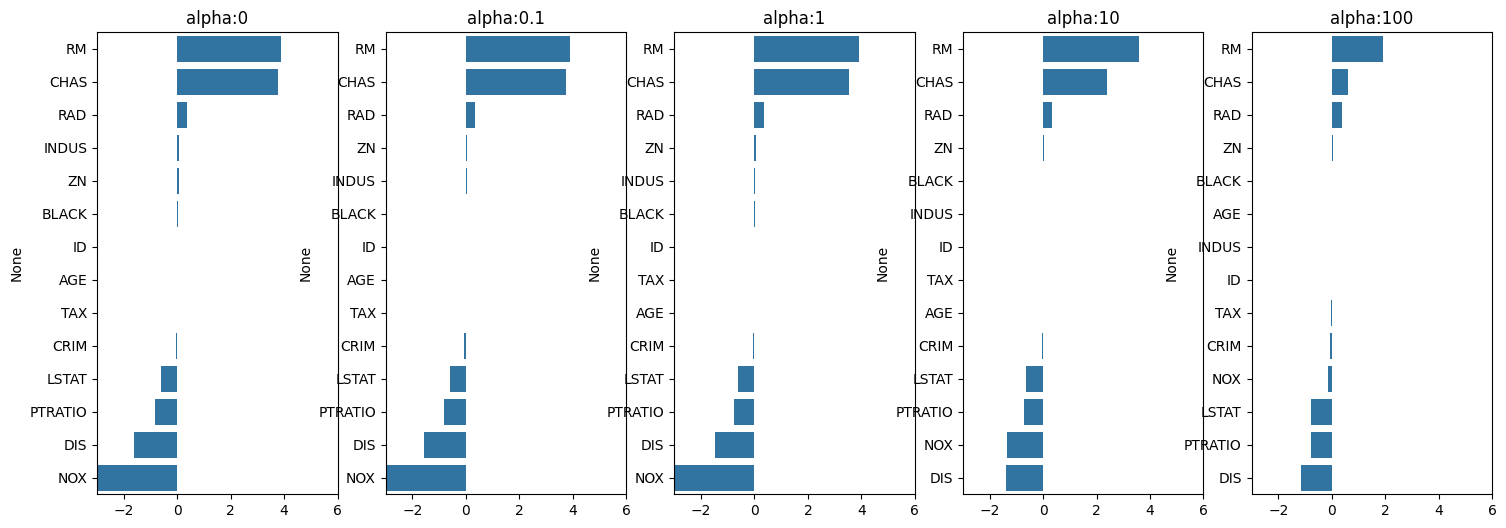

In [7]:
#각 alpha에 따른 회귀 계수 값을 시각화하기 위해 5개의 열로 된 맷플롯립 축 생성
fig, axs = plt.subplots(figsize=(18,6), nrows=1, ncols=5)
#각 alpha에 따른 회귀 계수 값을 데이터로 저장하기 위한 DataFrame 생성
coeff_df = pd.DataFrame()

#alphas 리스트 값을 차례로 입력해 회귀 계수 값 시각화 및 데이터 저장. pos는 axis 위치 지정
for pos, alpha in enumerate(alphas):
  ridge = Ridge(alpha = alpha)
  ridge.fit(X_data, y_target)
  #alpha에 따른 피처별로 회귀 계수를 Series로 변환하고 이를 DataFrame의 칼럼으로 추가
  coeff = pd.Series(data=ridge.coef_, index=X_data.columns)
  colname='alpha:'+str(alpha)
  coeff_df[colname] = coeff
  #막대 그래프로 각 alpha 값에서 회귀 계수를 시각화, 회귀 계수값이 높은 순으로 표현
  coeff = coeff.sort_values(ascending=False)
  axs[pos].set_title(colname)
  axs[pos].set_xlim(-3,6)
  sns.barplot(x=coeff.values, y=coeff.index, ax=axs[pos])

#for 문 바깥에서 맷플롯립 show 호출 및 alpha에 따른 피처별 회귀 계수를 DataFrame으로 표시
plt.show()

In [8]:
ridge_alphas = [0, 0.1, 1, 10, 100]
sort_column = 'alpha:'+str(ridge_alphas[0])
coeff_df.sort_values(by=sort_column, ascending=False)

,alpha:0,alpha:0.1,alpha:1,alpha:10,alpha:100
RM,3.879105,3.885374,3.895670,3.607230,1.934682
CHAS,3.780114,3.747765,3.523438,2.387089,0.617936
RAD,0.361780,0.358010,0.342046,0.338078,0.368277
INDUS,0.053408,0.048051,0.024342,0.003393,0.001813
ZN,0.049334,0.049629,0.051017,0.053450,0.057601
BLACK,0.011885,0.011975,0.012379,0.012759,0.012001
ID,-0.004548,-0.004575,-0.004682,-0.004535,-0.002975
AGE,-0.009510,-0.010783,-0.016231,-0.017729,0.003517
TAX,-0.011497,-0.011586,-0.012040,-0.013204,-0.015969
CRIM,-0.051706,-0.050663,-0.046170,-0.044030,-0.049125


In [19]:
#라쏘 회귀
from sklearn.linear_model import Lasso, ElasticNet

#alpha 값에 따른 회귀 모델의 폴드 평균 RMSE를 출력하고 회귀 계수값들을 DataFrame으로 반환
def get_linear_reg_eval(model_name, params=None, X_data_n=None, y_target_n=None, verbose = True, return_coeff=True):
  coeff_df = pd.DataFrame()
  if verbose : print('#######', model_name, '#######')
  for param in params :
    if model_name == 'Ridge' : model = Ridge(alpha=param)
    elif model_name == 'Lasso' : model = Lasso(alpha=param)
    elif model_name == 'ElasticNet':model = ElasticNet(alpha=param, l1_ratio=0.7)
    neg_mse_scores = cross_val_score(model, X_data_n, y_target_n, scoring='neg_mean_squared_error',cv=5)
    avg_rmse = np.mean(np.sqrt(-1*neg_mse_scores))
    print('alpha{0}일 때 5 폴드 세트의 평균 RMSE: {1:.3f}'.format(param, avg_rmse))
    #cross_val_score눈 evaluation metric만 반환하므로 모델을 다시 학습해 회귀 계수 추출

    model.fit(X_data_n, y_target_n)
    if return_coeff:
      #alpha에 따른 피처별 회귀 계수를 Series로 변환 후 DataFrame 칼럼으로 추가
      coeff = pd.Series(data=model.coef_, index=X_data_n.columns)
      colname = 'alpha:' + str(param)
      coeff_df[colname] = coeff

  return coeff_df



In [20]:
#라쏘에 사용될 alpha 파라미터 값을 정의하고 함수 호출
lasso_alphas = [0.07, 0.1, 0.5, 1, 3]
coeff_lasso_df = get_linear_reg_eval('Lasso', params=lasso_alphas, X_data_n=X_data, y_target_n=y_target)

####### Lasso #######
alpha0.07일 때 5 폴드 세트의 평균 RMSE: 6.676
alpha0.1일 때 5 폴드 세트의 평균 RMSE: 6.694
alpha0.5일 때 5 폴드 세트의 평균 RMSE: 6.792
alpha1일 때 5 폴드 세트의 평균 RMSE: 6.874
alpha3일 때 5 폴드 세트의 평균 RMSE: 7.289


In [21]:
#반환된 coeff_lasso_df를 첫 번째 칼럼순으로 내림차순 정렬해 회귀계수 DataFrame 출력
sort_column = 'alpha:'+str(lasso_alphas[0])
coeff_lasso_df.sort_values(by=sort_column, ascending=False)

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
RM,3.789422,3.703068,2.433588,0.777021,0.000000
CHAS,2.414972,1.889015,0.000000,0.000000,0.000000
RAD,0.322616,0.323814,0.307863,0.275728,0.082661
ZN,0.052265,0.052126,0.050765,0.049598,0.042806
BLACK,0.012957,0.013000,0.012543,0.011432,0.009233
INDUS,0.000000,0.000000,0.000000,0.000000,-0.000000
NOX,-0.000000,-0.000000,-0.000000,-0.000000,0.000000
ID,-0.004563,-0.004427,-0.002688,-0.000487,0.002727
TAX,-0.012861,-0.013017,-0.013912,-0.014620,-0.010163
AGE,-0.019378,-0.017419,0.002391,0.026682,0.048054


In [22]:
#엘라스틱넷 회귀 = L2 규제 + L1 규제
#엘라스틱넷에 사용될 alpha 파라미터 값들을 정의하고 함수 호출
#l1_ration = 0.7 고정
elastic_alphas = [0.07, 0.1, 0.5, 1, 3]
coeff_elastic_df = get_linear_reg_eval('ElasticNet', params=elastic_alphas, X_data_n=X_data, y_target_n=y_target)

####### ElasticNet #######
alpha0.07일 때 5 폴드 세트의 평균 RMSE: 6.567
alpha0.1일 때 5 폴드 세트의 평균 RMSE: 6.550
alpha0.5일 때 5 폴드 세트의 평균 RMSE: 6.451
alpha1일 때 5 폴드 세트의 평균 RMSE: 6.552
alpha3일 때 5 폴드 세트의 평균 RMSE: 7.122


In [23]:
#반환된 coeff_elastic_df를 첫 번째 칼럼순으로 내림차순 정렬해 회귀계수 DataFrame 출력
sort_column = 'alpha:'+str(elastic_alphas[0])
coeff_elastic_df.sort_values(by=sort_column, ascending=False)

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
RM,3.587271,3.425364,1.888087,0.866993,0.000000
CHAS,2.033697,1.590357,0.000000,0.000000,0.000000
RAD,0.331421,0.334408,0.333085,0.301208,0.158314
ZN,0.053222,0.053467,0.054122,0.052047,0.041782
BLACK,0.012895,0.012871,0.012148,0.011457,0.009952
INDUS,0.000000,0.000000,0.000000,0.000000,-0.000000
NOX,-0.000000,-0.000000,-0.000000,-0.000000,0.000000
ID,-0.004440,-0.004261,-0.002437,-0.000850,0.002149
TAX,-0.013308,-0.013576,-0.015121,-0.015324,-0.012327
AGE,-0.017433,-0.014892,0.007211,0.024523,0.049523


선형 회귀 모델을 위한 데이터 변환

In [26]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures

#method는 Standard, MinMax, Log 중 결정
#p_degree는 다항식 특성 추가할 때 적용. 2 이상 부여하지 않음
def get_scaled_data(method='None', p_degree=None, input_data=None):
  if method == 'Standard':
    scaled_data = StandardScaler().fit_transform(input_data)
  elif method == 'MinMax':
    scaled_data = MinMaxScaler().fit_transform(input_data)
  elif method == 'Log':
    scaled_data = np.log1p(input_data)
  else:
    scaled_data = input_data

  if p_degree != None:
    scaled_data = PolynomialFeatures(degree=p_degree, include_bias=False).fit_transform(scaled_data)

  return scaled_data

In [28]:
#Ridge의 alpha값을 다르게 적용하고 다양한 데이터 변환 방법에 따른 RMSE 추출
alphas = [0.1, 1, 10, 100]

#5개 방식으로 변환. 1. 원본 그대로 2. 표준정규 분포 3. 표준정규 분포+다항식 특성
#4. 최대최소 정규화 5. 최대최소 정규화 + 다항식 특성 6. 로그변환
scale_methods = [(None,None),('Standard',None),('Standard',2),('MinMax',None),('MinMax',2),('Log',None)]
for scale_method in scale_methods:
  X_data_scaled = get_scaled_data(method=scale_method[0], p_degree=scale_method[1], input_data=X_data)
  print('\n## 변환 유형:{0}, Polynomial Degree:{1}'.format(scale_method[0], scale_method[1]))
  get_linear_reg_eval('Ridge', params=alphas, X_data_n=X_data_scaled, y_target_n=y_target, verbose=False, return_coeff=False)


## 변환 유형:None, Polynomial Degree:None
alpha0.1일 때 5 폴드 세트의 평균 RMSE: 6.700
alpha1일 때 5 폴드 세트의 평균 RMSE: 6.613
alpha10일 때 5 폴드 세트의 평균 RMSE: 6.472
alpha100일 때 5 폴드 세트의 평균 RMSE: 6.207

## 변환 유형:Standard, Polynomial Degree:None
alpha0.1일 때 5 폴드 세트의 평균 RMSE: 6.731
alpha1일 때 5 폴드 세트의 평균 RMSE: 6.694
alpha10일 때 5 폴드 세트의 평균 RMSE: 6.466
alpha100일 때 5 폴드 세트의 평균 RMSE: 6.251

## 변환 유형:Standard, Polynomial Degree:2
alpha0.1일 때 5 폴드 세트의 평균 RMSE: 13.821
alpha1일 때 5 폴드 세트의 평균 RMSE: 8.922
alpha10일 때 5 폴드 세트의 평균 RMSE: 5.962
alpha100일 때 5 폴드 세트의 평균 RMSE: 5.140

## 변환 유형:MinMax, Polynomial Degree:None
alpha0.1일 때 5 폴드 세트의 평균 RMSE: 6.626
alpha1일 때 5 폴드 세트의 평균 RMSE: 6.267
alpha10일 때 5 폴드 세트의 평균 RMSE: 6.693
alpha100일 때 5 폴드 세트의 평균 RMSE: 8.229

## 변환 유형:MinMax, Polynomial Degree:2
alpha0.1일 때 5 폴드 세트의 평균 RMSE: 5.324
alpha1일 때 5 폴드 세트의 평균 RMSE: 4.892
alpha10일 때 5 폴드 세트의 평균 RMSE: 6.153
alpha100일 때 5 폴드 세트의 평균 RMSE: 7.323

## 변환 유형:Log, Polynomial Degree:None
alpha0.1일 때 5 폴드 세트의 평균 RMSE: 5.315
alpha1일 때 5 폴드 세트의 

로지스틱 회귀

In [29]:
from ast import increment_lineno
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

cancer = load_breast_cancer()

In [31]:
#로지스틱 회귀는 데이터의 정규 분포도에 따라 예측 성능 영향 -> 데이터에 표준 스케일링!
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

#StandardScaler()로 평균이 0, 분산이 1인 데이터 분포도 변환
scaler = StandardScaler()
data_scaled = scaler.fit_transform(cancer.data)

X_train, X_test, y_train, y_test = train_test_split(data_scaled, cancer.target, test_size=0.3, random_state=0)

In [33]:
from sklearn.metrics import accuracy_score, roc_auc_score

#로지스틱 회귀를 이용해 학습 및 예측 수행
#solver 인자값을 생성자로 입력하지 않으면 solver='lbfgs'
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
lr_preds = lr_clf.predict(X_test)
lr_preds_proba = lr_clf.predict_proba(X_test)[:,1]

#accuracy와 roc_auc 측정
print('accuracy: {0:.3f}, roc_auc : {1:.3f}'.format(accuracy_score(y_test, lr_preds), roc_auc_score(y_test, lr_preds_proba)))

accuracy: 0.977, roc_auc : 0.995


In [34]:
solvers = ['lbfgs','liblinear','newton-cg','sag','saga']

#여러 개의 solver 값별로 LogisticRegression 학습 후 성능 평가
for solver in solvers:
  lr_clf = LogisticRegression(solver=solver, max_iter=600)
  lr_clf.fit(X_train, y_train)
  lr_preds = lr_clf.predict(X_test)
  lr_preds_proba = lr_clf.predict_proba(X_test)[:,1]

  #accuracy와 roc_auc 측정
  print('solver:{0}, accuracy:{1:.3f}, roc_auc:{2:.3f}'.format(solver, accuracy_score(y_test, lr_preds), roc_auc_score(y_test, lr_preds_proba)))

solver:lbfgs, accuracy:0.977, roc_auc:0.995
solver:liblinear, accuracy:0.982, roc_auc:0.995
solver:newton-cg, accuracy:0.977, roc_auc:0.995
solver:sag, accuracy:0.982, roc_auc:0.995
solver:saga, accuracy:0.982, roc_auc:0.995


In [35]:
from sklearn.model_selection import GridSearchCV

params = {'solver':['liblinear','lbfgs'], 'penalty':['l2','l1'], 'C':[0.01, 0.1, 1, 5, 10]}
lr_clf = LogisticRegression()

grid_clf = GridSearchCV(lr_clf, param_grid=params, scoring='accuracy', cv=3)
grid_clf.fit(data_scaled, cancer.target)
print('최적 하이퍼 파라미터:{0}, 최적 평균 정확도:{1:.3f}'.format(grid_clf.best_params_, grid_clf.best_score_))

최적 하이퍼 파라미터:{'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}, 최적 평균 정확도:0.979
